In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 900

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


# Steps to do:

1. extract MPR data from the raw dataset
2. Plot the raw data
3. Preprocess - baseline correect it
4. Plot baseline corrected raw data
5. Smooth it with SG-DWT
6. Plot the smoothed pressure data
7. Bring in MPR based o2 released plot


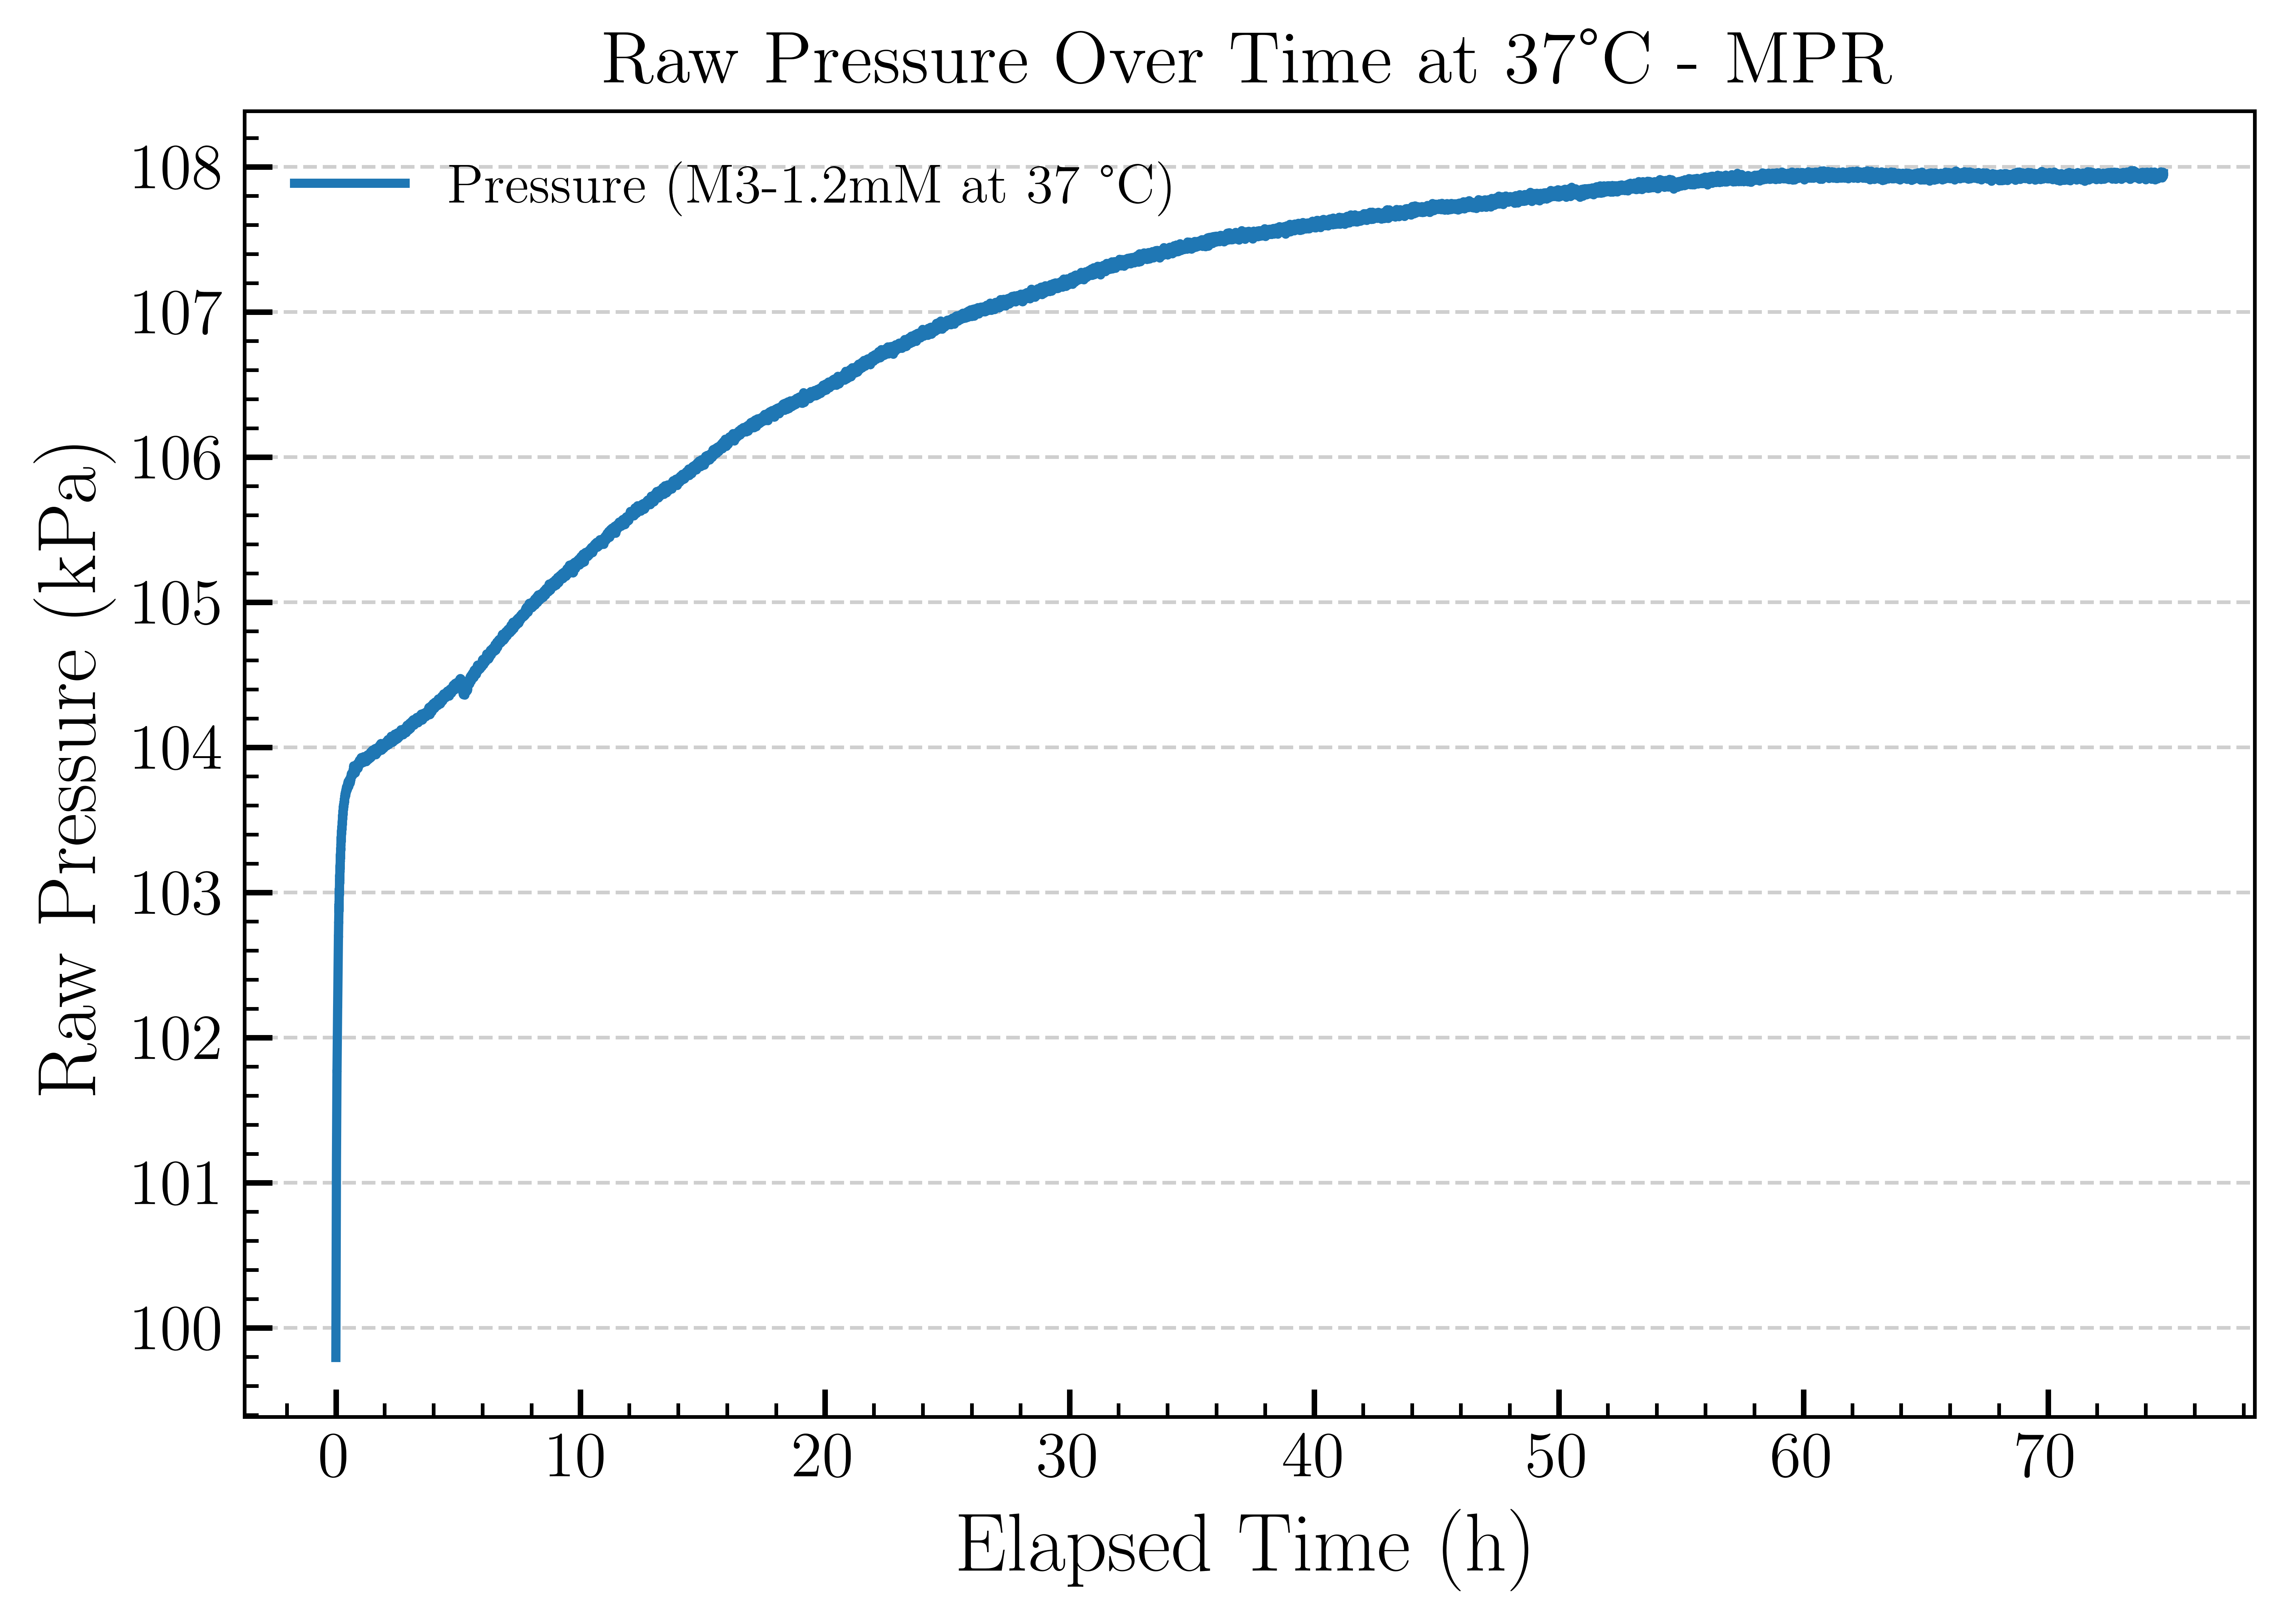

In [4]:
#raw dataset

main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Sample_M3\M3_1.2mM\Pressure_37deg\raw_meas\merged_pressure_log.csv"
df_time = pd.read_csv(main_path)

fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)

# print(df_time.head())
ax1.plot(df_time["Elapsed Time (hours)"],
         df_time["MPR-Sch2 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C - MPR', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()


            Date       Time  ABP2-Sch1 (kPa)  MPR-Sch2 (kPa)  Temperature (C)  \
1922  12.08.2025   12:01:20           6.6608        103.8010            36.75   
1930  12.08.2025   12:01:29           6.6633        103.8011            36.76   
1934  12.08.2025   12:01:34           6.6661        103.8031            36.78   
1943  12.08.2025   12:01:44           6.6689        103.8027            36.76   
1946  12.08.2025   12:01:48           6.6719        103.8068            36.79   

      Humidity (%RH)             Datetime  Elapsed Time (hours)  Weekday  \
1922           32.14  2025-08-12 12:01:20              0.617778  Tuesday   
1930           32.19  2025-08-12 12:01:29              0.620278  Tuesday   
1934           32.12  2025-08-12 12:01:34              0.621667  Tuesday   
1943           32.13  2025-08-12 12:01:44              0.624444  Tuesday   
1946           32.12  2025-08-12 12:01:48              0.625556  Tuesday   

      Is_Weekend  Is_Midnight  Logical_Day  
1922       

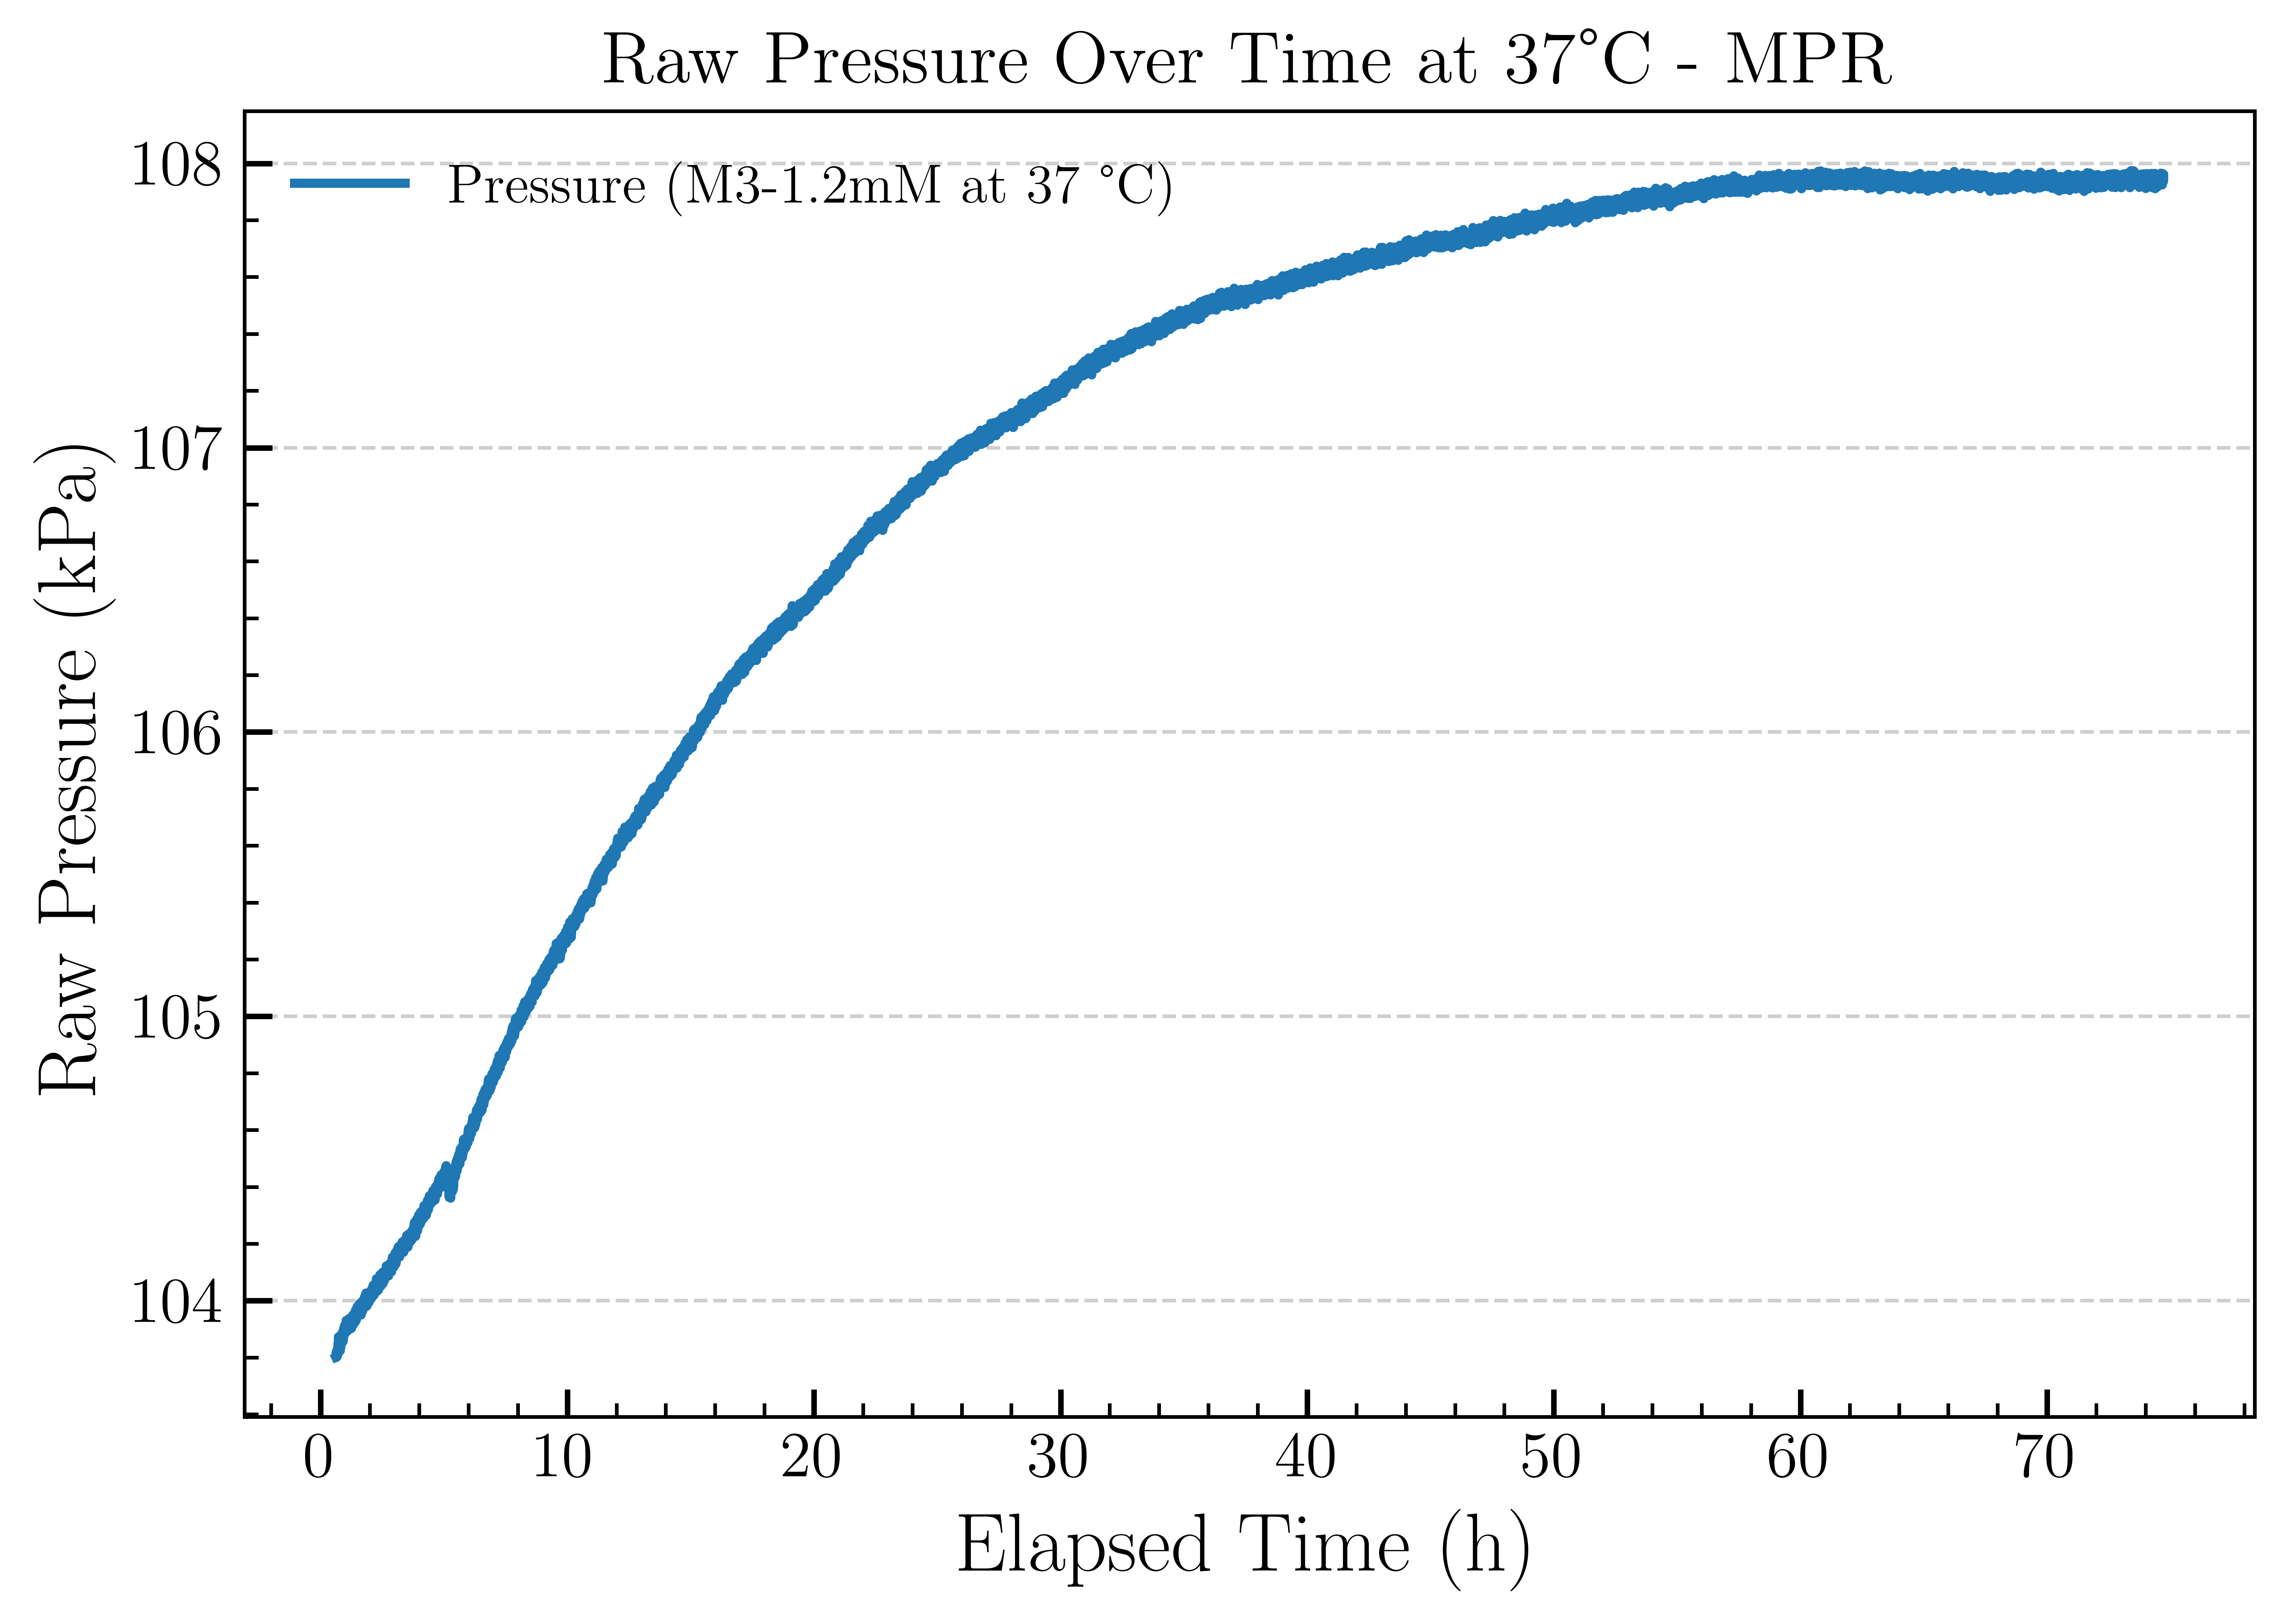

In [ ]:
df_sensor = df_time[df_time["MPR-Sch2 (kPa)"] > 103.8]


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)

# print(df_time.head())
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["MPR-Sch2 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C)')
print(df_sensor.head())

ax1.set_title('Raw Pressure Over Time at 37°C - MPR', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()


# Absolute to gauge


Look at the first 5 minutes of absolute readings (around 104 kPa).

Take their average (say 104.25).

Treat that as atmospheric pressure.

Subtract it from all readings → now you have gauge pressure.

First data point ≈ 0, later data points show how much pressure increased above atmosphere.

Estimated atmospheric baseline (first 5 min): 103.814 kPa
First gauge value (should be ~0): -0.0131 kPa


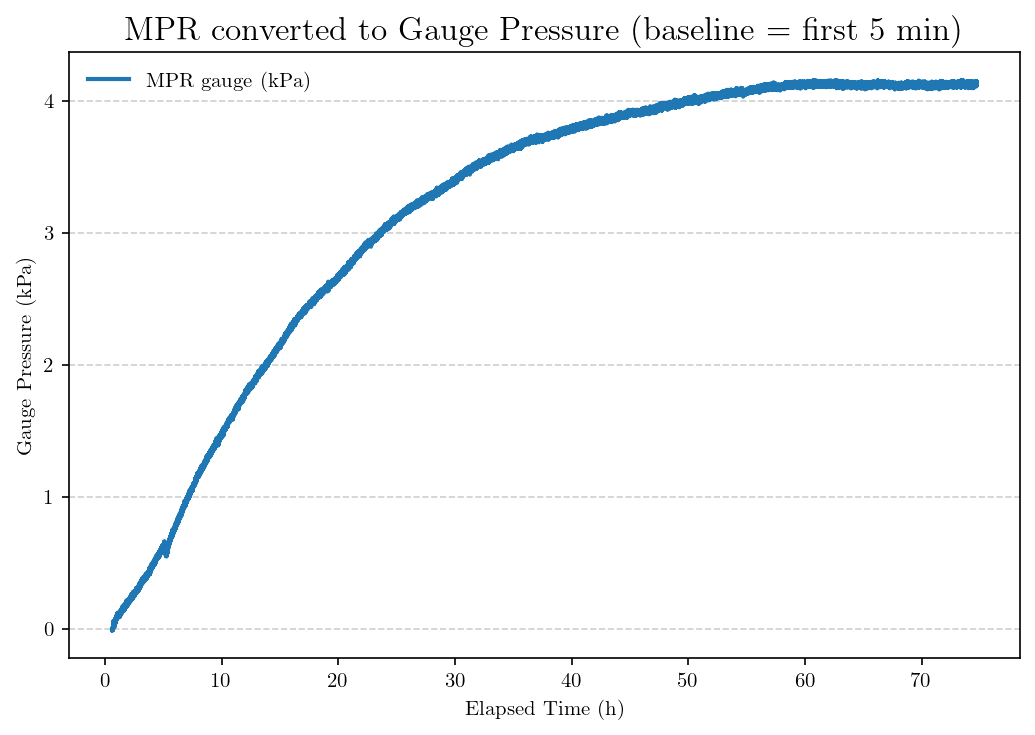

4.160170796460179
            Date       Time  ABP2-Sch1 (kPa)  MPR-Sch2 (kPa)  Temperature (C)  \
1922  12.08.2025   12:01:20           6.6608        103.8010            36.75   
1930  12.08.2025   12:01:29           6.6633        103.8011            36.76   
1934  12.08.2025   12:01:34           6.6661        103.8031            36.78   
1943  12.08.2025   12:01:44           6.6689        103.8027            36.76   
1946  12.08.2025   12:01:48           6.6719        103.8068            36.79   

      Humidity (%RH)             Datetime  Elapsed Time (hours)  Weekday  \
1922           32.14  2025-08-12 12:01:20              0.617778  Tuesday   
1930           32.19  2025-08-12 12:01:29              0.620278  Tuesday   
1934           32.12  2025-08-12 12:01:34              0.621667  Tuesday   
1943           32.13  2025-08-12 12:01:44              0.624444  Tuesday   
1946           32.12  2025-08-12 12:01:48              0.625556  Tuesday   

      Is_Weekend  Is_Midnight  Logical

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Convert MPR absolute -> gauge (zeroed to first 5 min) ---

# Coerce to numeric and drop non-finite
t = pd.to_numeric(df_sensor["Elapsed Time (hours)"], errors="coerce").to_numpy()
p_abs = pd.to_numeric(df_sensor["MPR-Sch2 (kPa)"],    errors="coerce").to_numpy()
good = np.isfinite(t) & np.isfinite(p_abs)
t, p_abs = t[good], p_abs[good]

# Baseline window = first 5 minutes relative to earliest timestamp
t0 = np.min(t)
baseline_end = t0 + 5.0/60.0  # 5 minutes in hours
mask_base = (t >= t0) & (t <= baseline_end)

# Fallback if too few points in the first 5 minutes
if mask_base.sum() < 3:
    # estimate cadence and take first ~5 minutes worth of samples
    dt = np.median(np.diff(np.sort(t)))
    if not np.isfinite(dt) or dt <= 0:
        dt = 1.0/3600.0  # assume 1 Hz if unknown
    n_needed = max(3, int(round((5.0/60.0)/dt)))
    n_needed = min(n_needed, len(t))
    order = np.argsort(t)
    mask_base = np.zeros_like(t, dtype=bool)
    mask_base[order[:n_needed]] = True

atm_est = np.mean(p_abs[mask_base])  # ~104 kPa typically

# Gauge pressure (ΔP): subtract atmospheric baseline
p_gauge = p_abs - atm_est

# Write back aligned with original df (keep only 'good' rows)
df_sensor = df_sensor.loc[good].copy()
df_sensor["MPR gauge (kPa)"] = p_gauge

print(f"Estimated atmospheric baseline (first 5 min): {atm_est:.3f} kPa")
print(f"First gauge value (should be ~0): {p_gauge[0]:.4f} kPa")

# --- Quick plot ---
fig, ax = plt.subplots(figsize=(7,5), dpi=150)
ax.plot(t, p_gauge, lw=2.0, label="MPR gauge (kPa)")



ax.set_title("MPR converted to Gauge Pressure (baseline = first 5 min)", fontsize=16)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Gauge Pressure (kPa)")
ax.legend(frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


pd.DataFrame(df_sensor).to_csv(r"C:\Users\chand\Documents\GitHub\Thesis\MPR_RT_raw", index=False)

print(max(p_gauge))
print(df_sensor.head())

# If i had to calculate o2 with no smoothing of MPR datasets


In [30]:
# Constants



plot_time = df_sensor["Elapsed Time (hours)"].to_numpy()
plot_mpr_dwt = df_sensor["MPR gauge (kPa)"].to_numpy()
plot_temperature = df_sensor["Temperature (C)"].to_numpy()
volume_solution_L = 0.006 # 6ml
concentration_mM = 1.2

max_o2_umol = concentration_mM * volume_solution_L * 1e3 # micromol

# pressure to micromol using ideal gas law
V_headspace_L = 0.004  # 4 ml = 0.004 L
R = 0.082057  # L·atm/mol·K

pressure_atm = plot_mpr_dwt / 101.325      # Convert pressure (kPa) to atm 
temperature_K = plot_temperature + 273.15   # temperature to Kelvin

# Compute µmol O₂
o2_micromol = ((pressure_atm * V_headspace_L) / (R * temperature_K)) * 1e6

ratio = volume_solution_L / V_headspace_L



df_o2_export = pd.DataFrame({
    "Sample": "1.2 mM @ 37deg",
    "Time (h)": plot_time,
    "DWT denoised pressure (kPa)": plot_mpr_dwt,
    "calibrated temperature (C)": plot_temperature,
    "O2 Released (µmol)": o2_micromol,
    "% Conversion": (o2_micromol / max_o2_umol) * 100,
    "Soln/Headspace Ratio": ratio,
    "Max O2 Possible (µmol)": max_o2_umol
})

print(df_o2_export.head())

           Sample  Time (h)  DWT denoised pressure (kPa)  \
0  1.2 mM @ 37deg  0.617778                    -0.013129   
1  1.2 mM @ 37deg  0.620278                    -0.013029   
2  1.2 mM @ 37deg  0.621667                    -0.011029   
3  1.2 mM @ 37deg  0.624444                    -0.011429   
4  1.2 mM @ 37deg  0.625556                    -0.007329   

   calibrated temperature (C)  O2 Released (µmol)  % Conversion  \
0                       36.75           -0.020382     -0.283082   
1                       36.76           -0.020226     -0.280917   
2                       36.78           -0.017120     -0.237780   
3                       36.76           -0.017742     -0.246420   
4                       36.79           -0.011376     -0.158006   

   Soln/Headspace Ratio  Max O2 Possible (µmol)  
0                   1.5                     7.2  
1                   1.5                     7.2  
2                   1.5                     7.2  
3                   1.5             

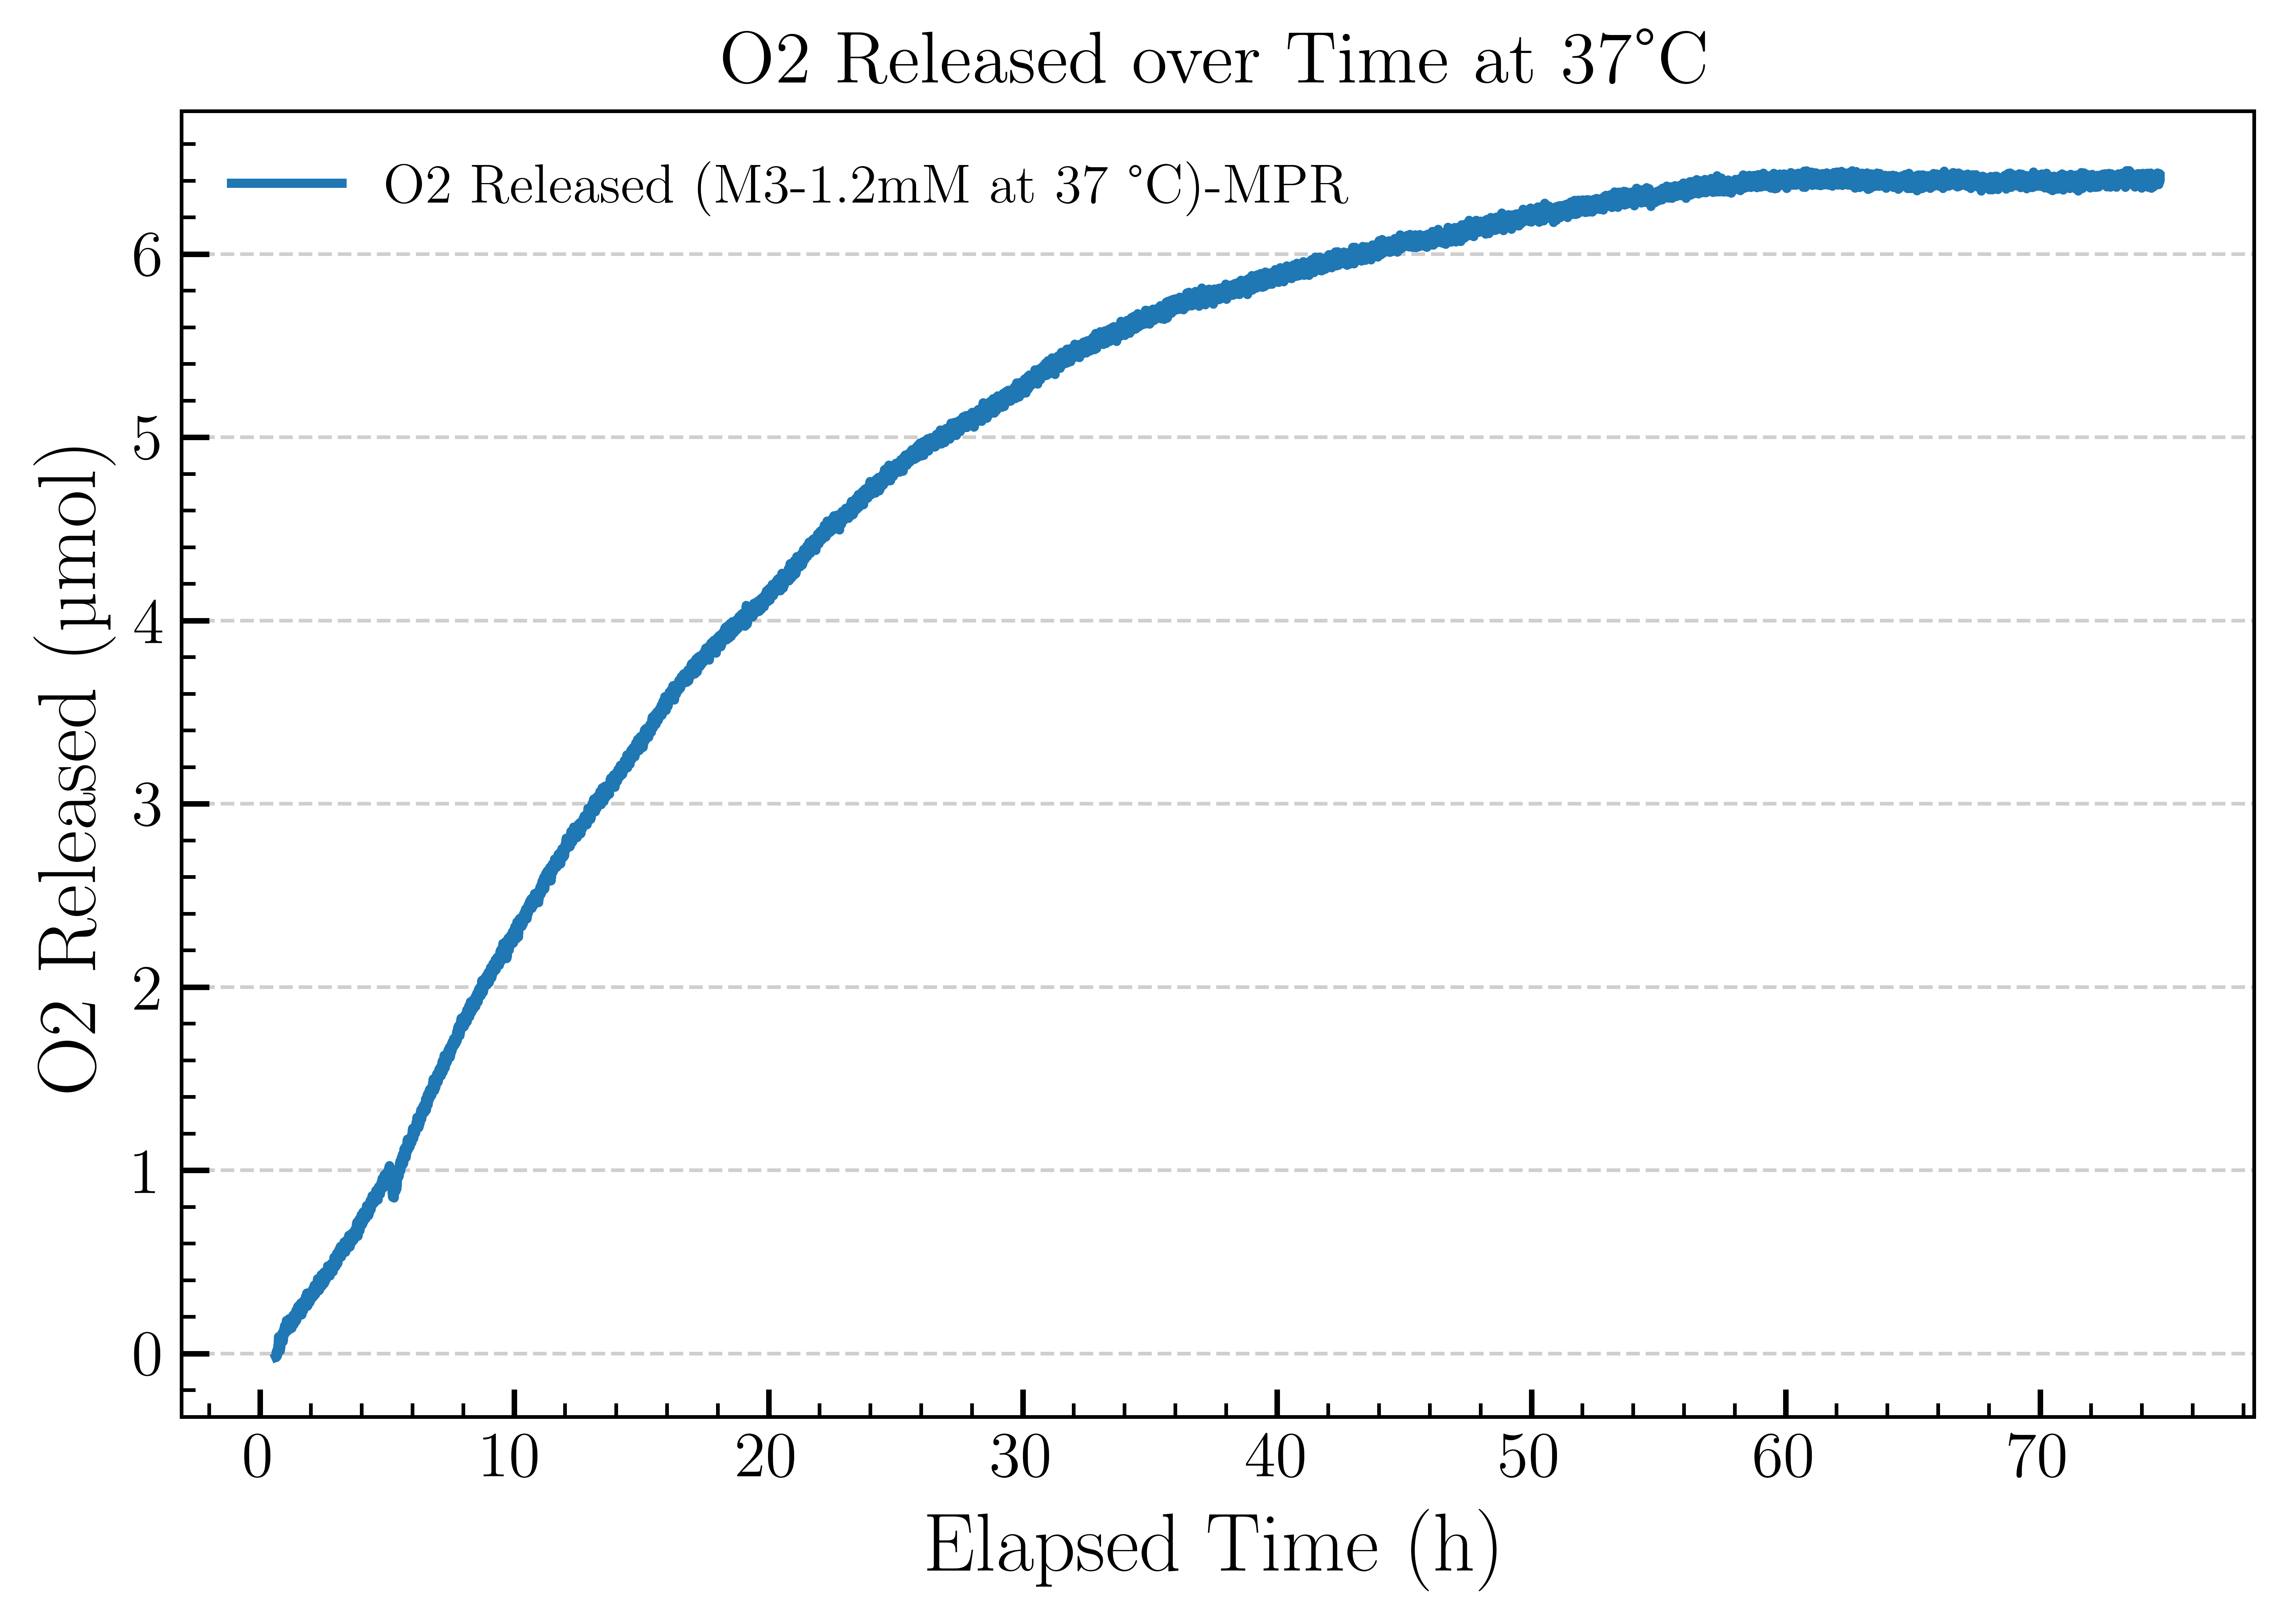

6.454954154652426


In [31]:
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_o2_export["Time (h)"],
         df_o2_export["O2 Released (µmol)"],
         lw=2.0, color="tab:blue",
         label=r'O2 Released (M3-1.2mM at 37 °C)-MPR')

ax1.set_title('O2 Released over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="O2 Released (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

print(max(df_o2_export["O2 Released (µmol)"]))

# Smoothing with SG and DWT below:

           Sample  Time (h)  DWT denoised pressure (kPa)  \
0  1.2 mM @ 37deg  0.701111                     0.005987   
1  1.2 mM @ 37deg  0.701389                     0.006033   
2  1.2 mM @ 37deg  0.701667                     0.006078   
3  1.2 mM @ 37deg  0.701945                     0.006124   
4  1.2 mM @ 37deg  0.702223                     0.006169   

   calibrated temperature (C)  O2 Released (µmol)  % Conversion  \
0                   36.779989            0.009294      0.129082   
1                   36.770000            0.009365      0.130067   
2                   36.769989            0.009435      0.131048   
3                   36.760023            0.009506      0.132033   
4                   36.779989            0.009576      0.133007   

   Smoothed pressure from just SG (kPa)  Soln/Headspace Ratio  \
0                              0.013701                   1.5   
1                              0.014586                   1.5   
2                              0.015071  

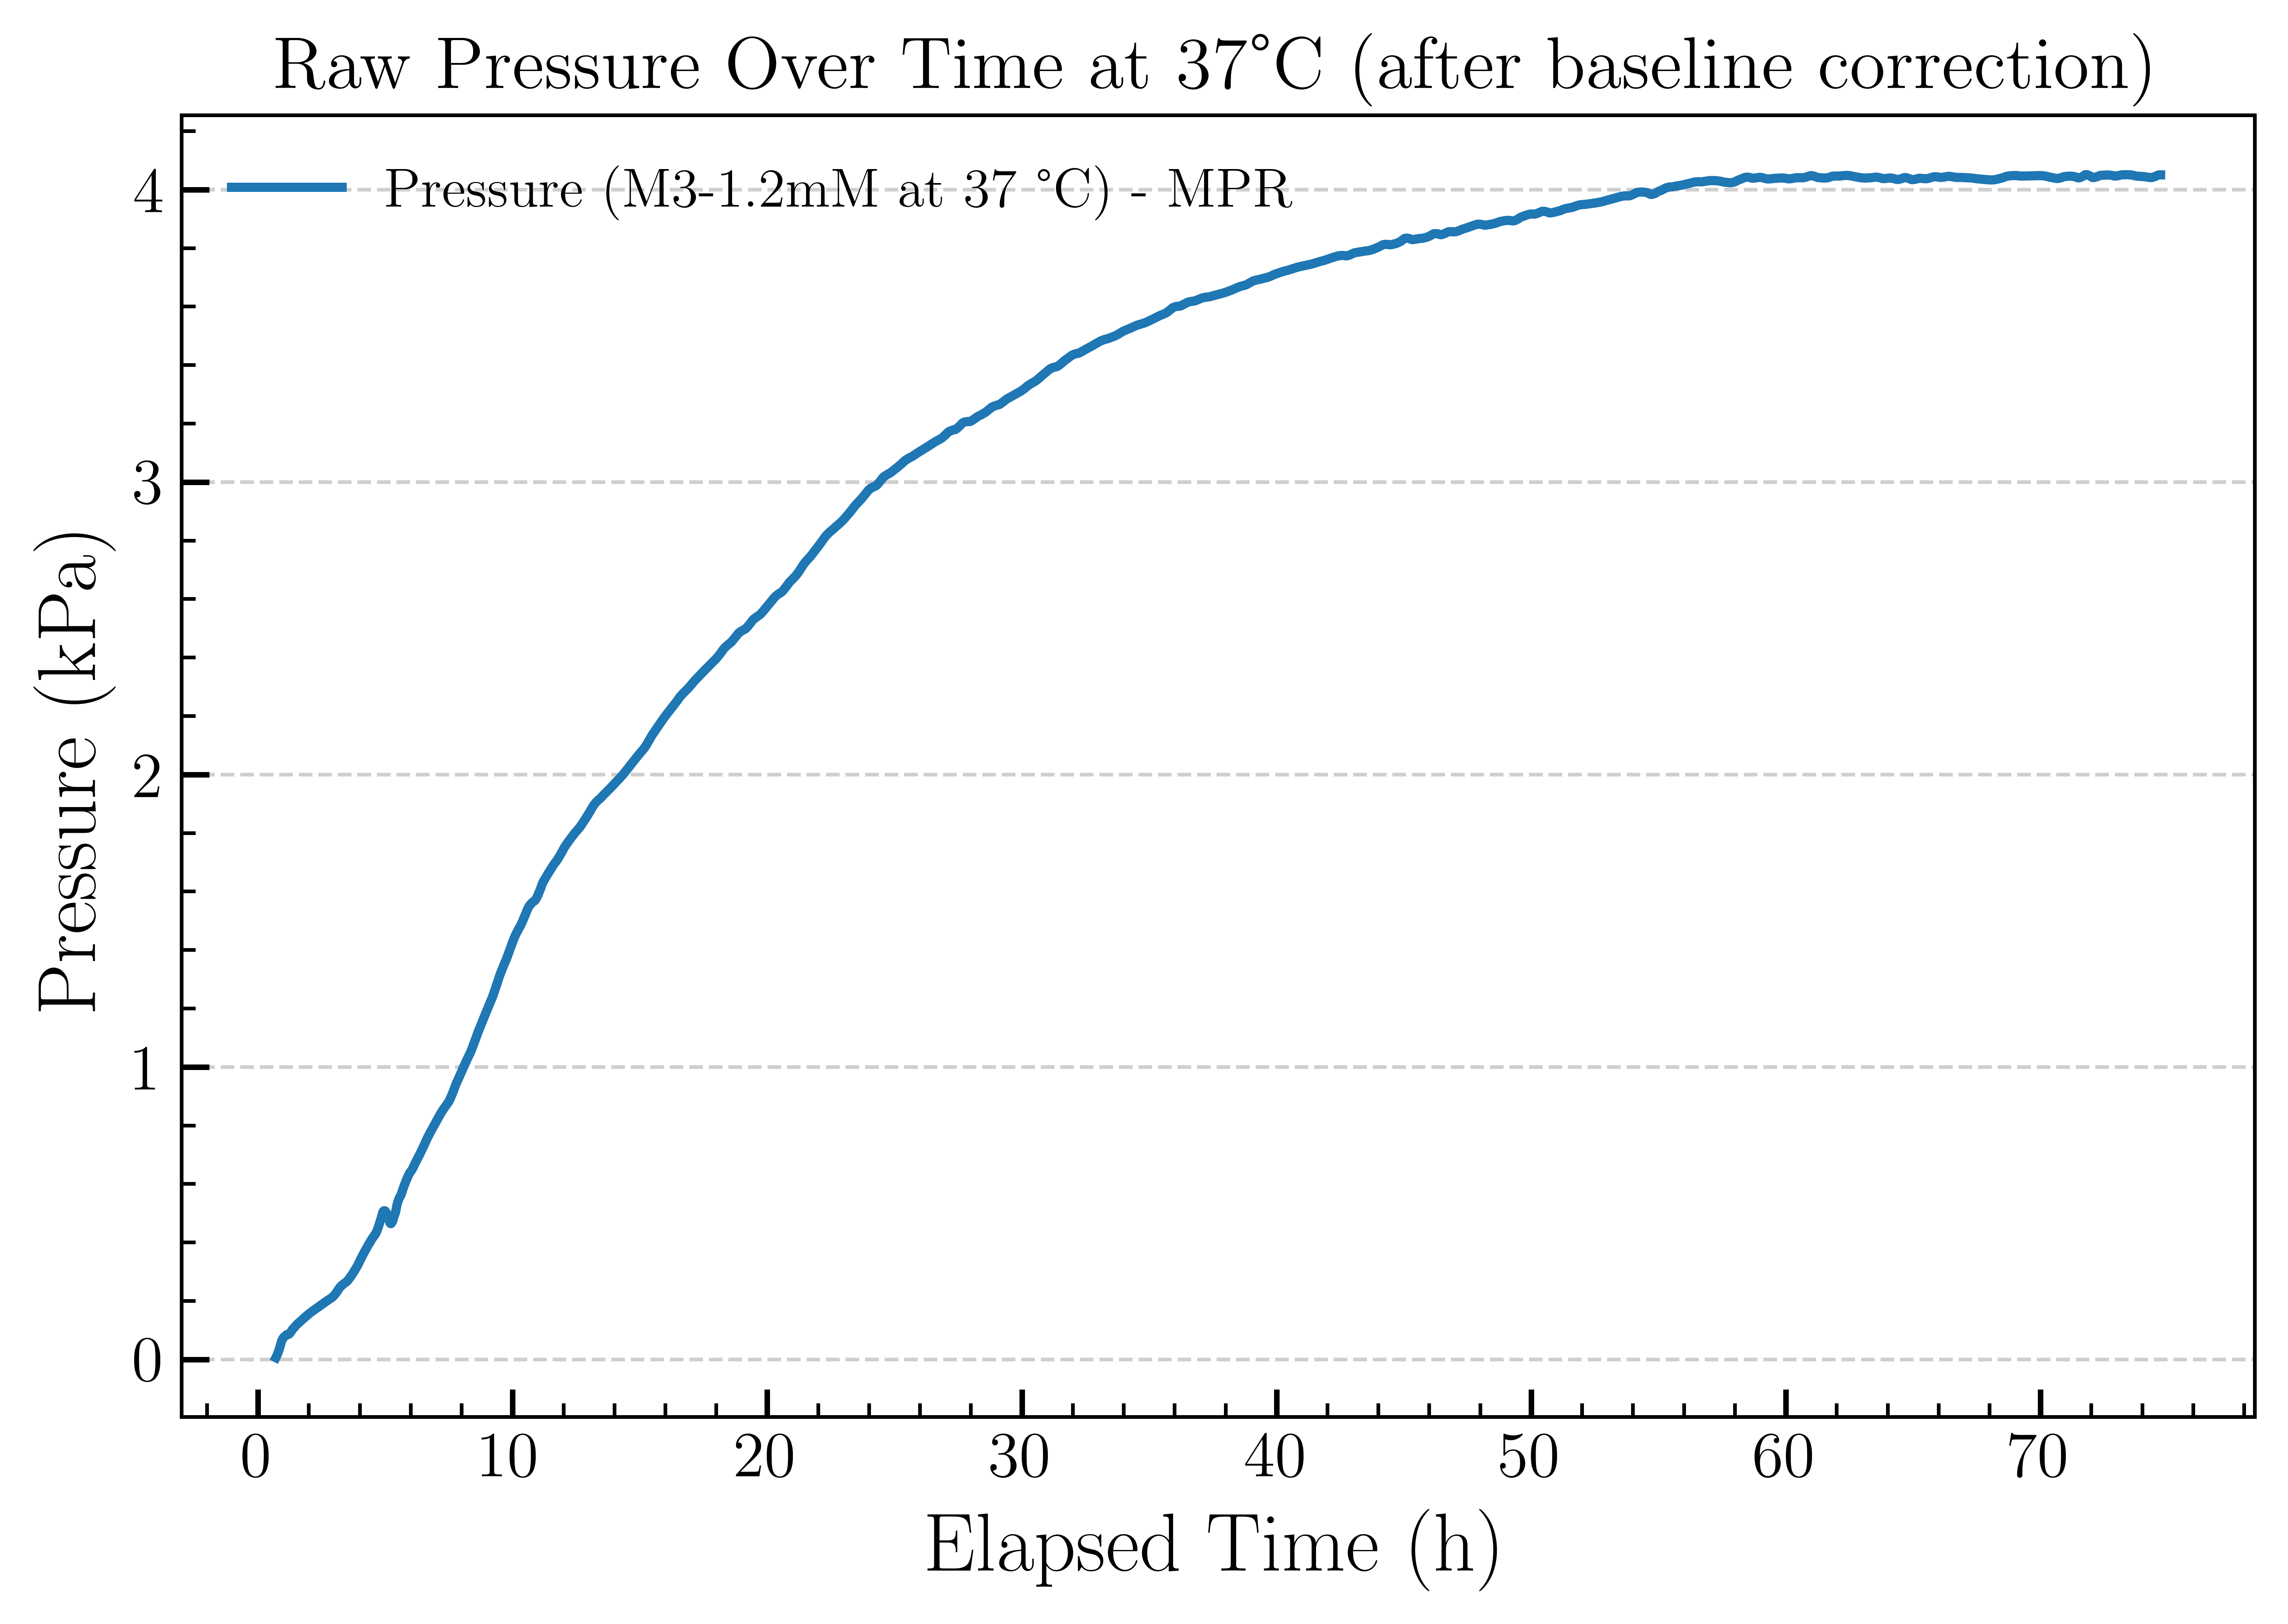

4.051502052225364


In [27]:
mpr = r"C:\Users\chand\Documents\GitHub\Thesis\M3_MPR_1.2mM_37deg_pressure_o2_release.csv"

df_mptr = pd.read_csv(mpr)
print(df_mptr.head())


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_mptr["Time (h)"],
         df_mptr["DWT denoised pressure (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M3-1.2mM at 37 °C) - MPR')

ax1.set_title('Raw Pressure Over Time at 37°C (after baseline correction)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

print(max(df_mptr["DWT denoised pressure (kPa)"]))

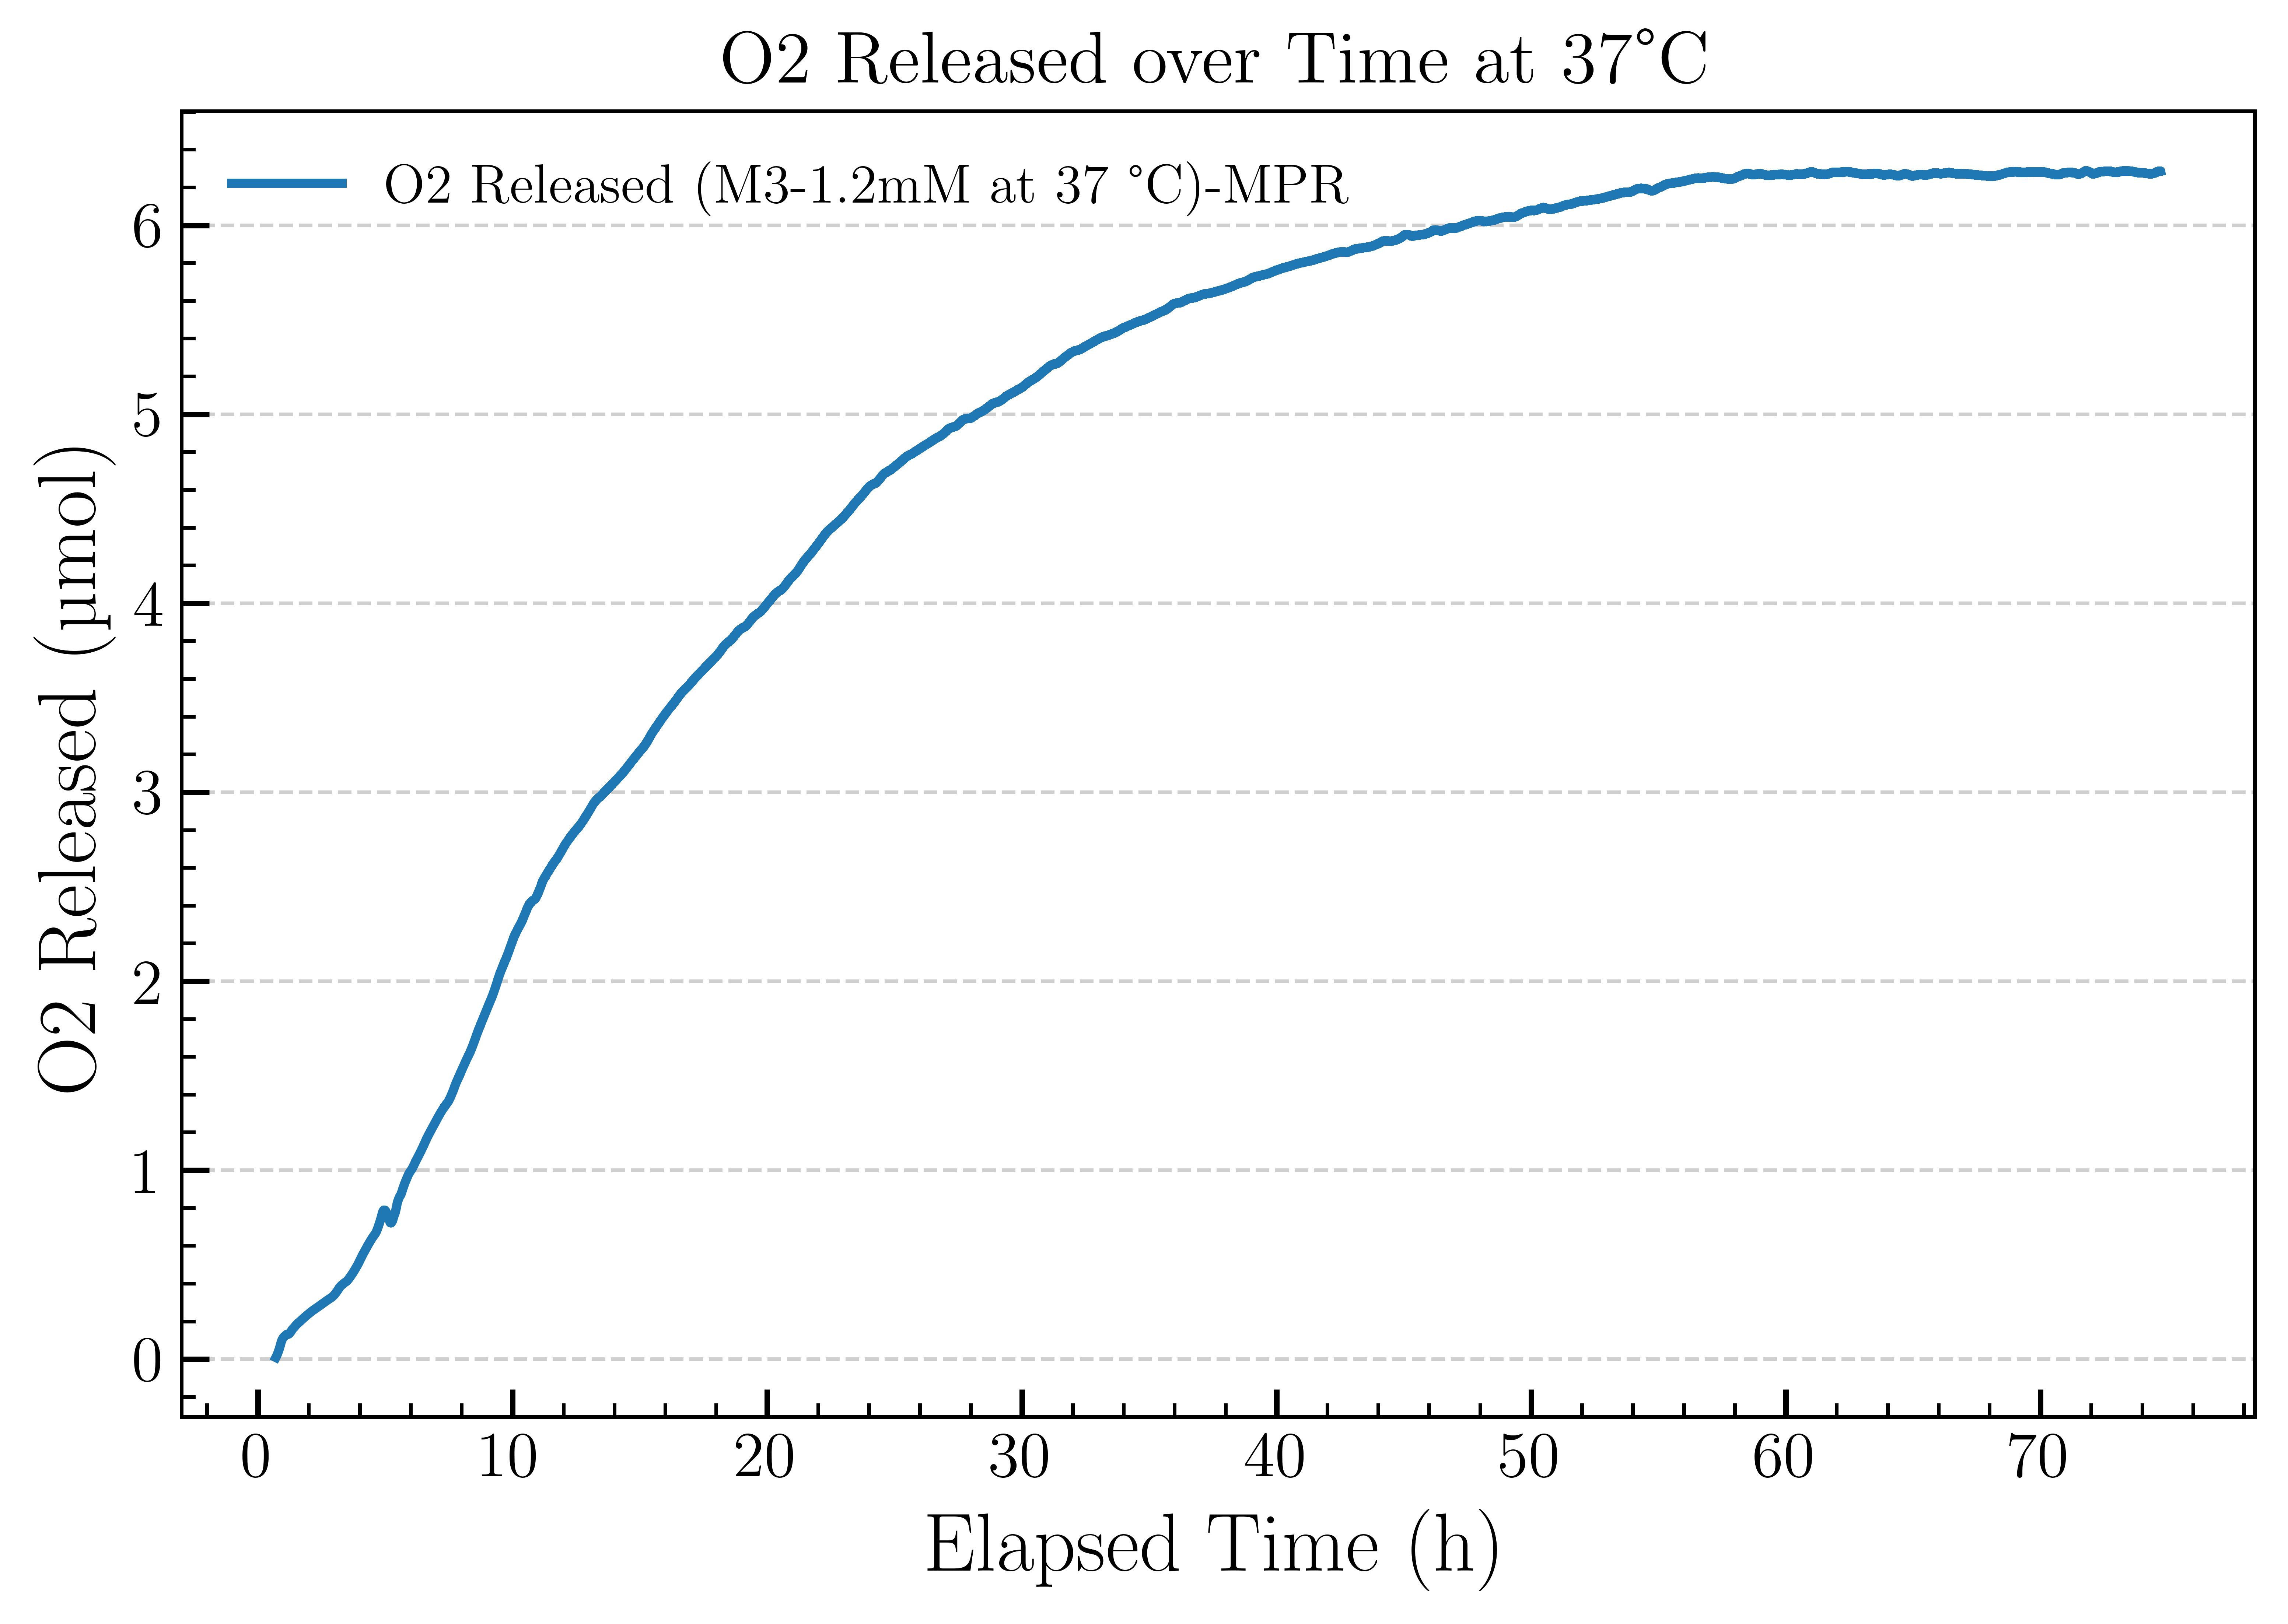

6.288760438649412


In [28]:
fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_mptr["Time (h)"],
         df_mptr["O2 Released (µmol)"],
         lw=2.0, color="tab:blue",
         label=r'O2 Released (M3-1.2mM at 37 °C)-MPR')

ax1.set_title('O2 Released over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="O2 Released (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.show()

print(max(df_mptr["O2 Released (µmol)"]))

With smoothing, 6.2umol in headspace and without smoothing, 6.4umol in headspace